Training baseline 'production' model...
Epoch 0: Train Loss = 0.6654, Val Acc = 0.7532
Epoch 10: Train Loss = 0.3582, Val Acc = 0.8136
Epoch 20: Train Loss = 0.3297, Val Acc = 0.8371

Initial 'Production' Model:
Val Accuracy: 0.8416
Test Accuracy: 0.8553

Continuing training with different methods...

PRODUCTION MODEL UPDATE COMPARISON
Method               Val Acc    Test Acc   Forgetting   Conf Drop   
--------------------------------------------------------------------------------
Initial Model        0.8416     0.8553     0            0.0         
Baseline Continued   0.8479     0.8571     1657         1606.8      
Discrete Penalty     0.8479     0.8571     0            12307.0     
Smooth Penalty       0.8479     0.8571     0            0.0         

Key Insights:
- Discrete penalty reduced forgetting by 100.0%
- Smooth penalty reduced forgetting by 100.0%
- Discrete penalty accuracy cost: 0.00%
- Smooth penalty accuracy cost: 0.00%


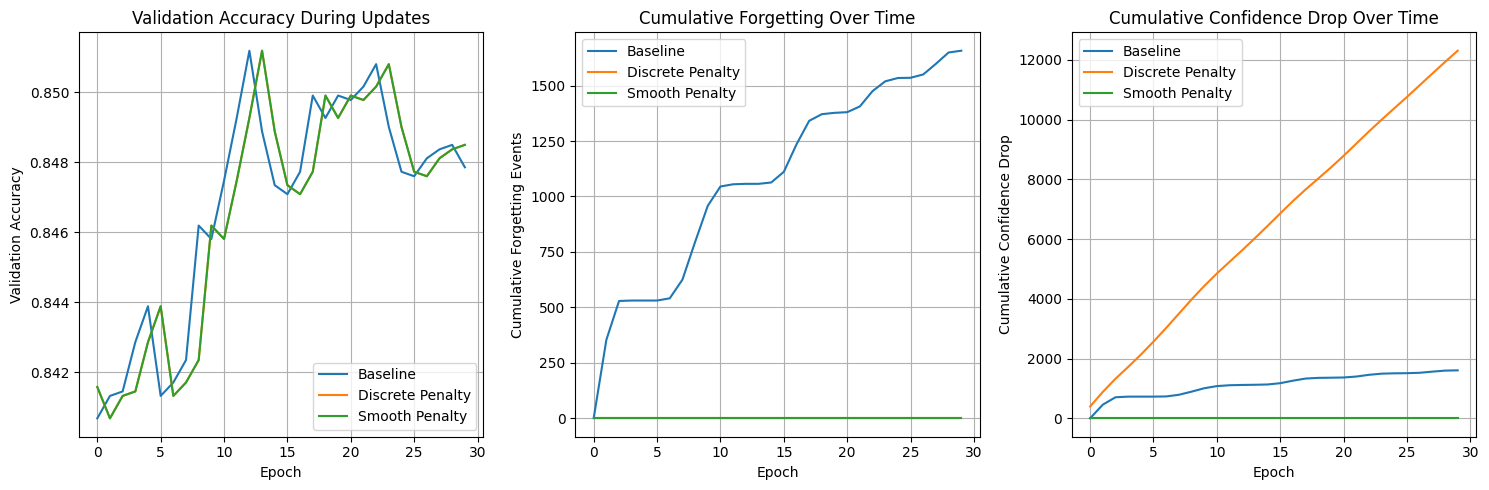

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from collections import defaultdict

# Simple MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()

# Load and preprocess Adult dataset
def load_adult_data():
    # Load Adult dataset
    adult = fetch_openml('adult', version=2, as_frame=True)
    X = adult.data
    y = (adult.target == '>50K').astype(int)

    # Simple preprocessing
    X_encoded = pd.get_dummies(X, drop_first=True)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Convert to tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.FloatTensor(y_train.values)
    y_val = torch.FloatTensor(y_val.values)
    y_test = torch.FloatTensor(y_test.values)

    return X_train, X_val, X_test, y_train, y_val, y_test

# Training functions
def train_baseline_model(X_train, y_train, X_val, y_val, epochs=30):
    """Train initial 'production' model"""
    model = MLP(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    print("Training baseline 'production' model...")
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_acc = ((val_pred > 0.5).float() == y_val).float().mean()
                print(f"Epoch {epoch}: Train Loss = {loss:.4f}, Val Acc = {val_acc:.4f}")

    return model

def continue_training_discrete(model, X_train, y_train, X_val, y_val,
                             penalty_lambda=0.0, epochs=50):
    """Continue training with discrete forgetting penalty"""
    model = model  # Use the passed model
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    # Get initial validation predictions
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        prev_val_correct = (y_val_pred > 0.5).float()

    metrics = {
        'forgetting_events': [],
        'val_accuracy': [],
        'confidence_drops': []
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass on training data
        y_pred = model(X_train)
        base_loss = loss_fn(y_pred, y_train)

        # Eval on validation to compute penalty
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val)
            val_pred_labels = (y_val_pred > 0.5).float()
            val_acc = (val_pred_labels == y_val).float().mean().item()

            # Compute discrete forgetting
            forgetting = int(((prev_val_correct == 1) & (val_pred_labels == 0)).sum().item())

            # Compute confidence drops (for tracking)
            confidence_drop = torch.clamp(prev_val_correct - y_val_pred, min=0.0).sum().item()

            metrics['forgetting_events'].append(forgetting)
            metrics['val_accuracy'].append(val_acc)
            metrics['confidence_drops'].append(confidence_drop)

        # Add discrete penalty
        penalty = penalty_lambda * forgetting
        total_loss = base_loss + penalty

        total_loss.backward()
        optimizer.step()

        # Update for next iteration
        with torch.no_grad():
            prev_val_correct = (model(X_val) > 0.5).float()

    return model, metrics

def continue_training_smooth(model, X_train, y_train, X_val, y_val,
                           penalty_lambda=0.0, epochs=50):
    """Continue training with smooth forgetting penalty"""
    model = model  # Use the passed model
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    # Get initial validation predictions
    model.eval()
    with torch.no_grad():
        prev_val_probs = model(X_val).clone()

    metrics = {
        'forgetting_events': [],
        'val_accuracy': [],
        'confidence_drops': []
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass on training data
        y_pred = model(X_train)
        base_loss = loss_fn(y_pred, y_train)

        # Eval on validation to compute penalty
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val)
            val_pred_labels = (y_val_pred > 0.5).float()
            val_acc = (val_pred_labels == y_val).float().mean().item()

            # Compute discrete forgetting (for tracking)
            prev_correct = (prev_val_probs > 0.5).float()
            forgetting = int(((prev_correct == 1) & (val_pred_labels == 0)).sum().item())

            metrics['forgetting_events'].append(forgetting)
            metrics['val_accuracy'].append(val_acc)

        # Compute smooth forgetting penalty
        penalty = 0.0
        if penalty_lambda > 0:
            # Confidence drop penalty for previously correct examples
            prev_correct_mask = (prev_val_probs > 0.5).float() == y_val
            confidence_drop = torch.clamp(prev_val_probs - y_val_pred, min=0.0)
            penalty = penalty_lambda * (confidence_drop * prev_correct_mask).sum()

            # Track confidence drops
            metrics['confidence_drops'].append(confidence_drop.sum().item())

        total_loss = base_loss + penalty
        total_loss.backward()
        optimizer.step()

        # Update for next iteration
        with torch.no_grad():
            prev_val_probs = model(X_val).clone()

    return model, metrics

def continue_training_baseline(model, X_train, y_train, X_val, y_val, epochs=50):
    """Continue training without any forgetting penalty"""
    model = model  # Use the passed model
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    # Get initial validation predictions for tracking
    model.eval()
    with torch.no_grad():
        prev_val_probs = model(X_val).clone()

    metrics = {
        'forgetting_events': [],
        'val_accuracy': [],
        'confidence_drops': []
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

        # Track metrics
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val)
            val_pred_labels = (y_val_pred > 0.5).float()
            val_acc = (val_pred_labels == y_val).float().mean().item()

            # Compute forgetting for tracking
            prev_correct = (prev_val_probs > 0.5).float()
            forgetting = int(((prev_correct == 1) & (val_pred_labels == 0)).sum().item())

            # Compute confidence drops
            confidence_drop = torch.clamp(prev_val_probs - y_val_pred, min=0.0).sum().item()

            metrics['forgetting_events'].append(forgetting)
            metrics['val_accuracy'].append(val_acc)
            metrics['confidence_drops'].append(confidence_drop)

            prev_val_probs = y_val_pred.clone()

    return model, metrics

def evaluate_model(model, X_test, y_test):
    """Evaluate model on test set"""
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        test_acc = ((y_pred > 0.5).float() == y_test).float().mean().item()
        return test_acc

# Main evaluation function
def run_comparison():
    # Load data
    X_train, X_val, X_test, y_train, y_val, y_test = load_adult_data()

    # Train baseline 'production' model
    baseline_model = train_baseline_model(X_train, y_train, X_val, y_val)
    initial_val_acc = evaluate_model(baseline_model, X_val, y_val)
    initial_test_acc = evaluate_model(baseline_model, X_test, y_test)

    print(f"\nInitial 'Production' Model:")
    print(f"Val Accuracy: {initial_val_acc:.4f}")
    print(f"Test Accuracy: {initial_test_acc:.4f}")

    # Create copies for each method
    import copy
    model_baseline = copy.deepcopy(baseline_model)
    model_discrete = copy.deepcopy(baseline_model)
    model_smooth = copy.deepcopy(baseline_model)

    # Continue training with different methods
    print("\nContinuing training with different methods...")

    # Baseline continued training
    model_baseline, metrics_baseline = continue_training_baseline(
        model_baseline, X_train, y_train, X_val, y_val, epochs=30
    )

    # Discrete forgetting penalty
    model_discrete, metrics_discrete = continue_training_discrete(
        model_discrete, X_train, y_train, X_val, y_val,
        penalty_lambda=1.0, epochs=30
    )

    # Smooth forgetting penalty
    model_smooth, metrics_smooth = continue_training_smooth(
        model_smooth, X_train, y_train, X_val, y_val,
        penalty_lambda=0.1, epochs=30
    )

    # Final evaluation
    results = {
        'Initial Model': {
            'val_acc': initial_val_acc,
            'test_acc': initial_test_acc,
            'total_forgetting': 0,
            'total_confidence_drop': 0
        },
        'Baseline Continued': {
            'val_acc': evaluate_model(model_baseline, X_val, y_val),
            'test_acc': evaluate_model(model_baseline, X_test, y_test),
            'total_forgetting': sum(metrics_baseline['forgetting_events']),
            'total_confidence_drop': sum(metrics_baseline['confidence_drops'])
        },
        'Discrete Penalty': {
            'val_acc': evaluate_model(model_discrete, X_val, y_val),
            'test_acc': evaluate_model(model_discrete, X_test, y_test),
            'total_forgetting': sum(metrics_discrete['forgetting_events']),
            'total_confidence_drop': sum(metrics_discrete['confidence_drops'])
        },
        'Smooth Penalty': {
            'val_acc': evaluate_model(model_smooth, X_val, y_val),
            'test_acc': evaluate_model(model_smooth, X_test, y_test),
            'total_forgetting': sum(metrics_smooth['forgetting_events']),
            'total_confidence_drop': sum(metrics_smooth['confidence_drops'])
        }
    }

    return results, metrics_baseline, metrics_discrete, metrics_smooth

def print_results(results):
    """Print results in a nice table format"""
    print("\n" + "="*80)
    print("PRODUCTION MODEL UPDATE COMPARISON")
    print("="*80)

    print(f"{'Method':<20} {'Val Acc':<10} {'Test Acc':<10} {'Forgetting':<12} {'Conf Drop':<12}")
    print("-" * 80)

    for method, metrics in results.items():
        print(f"{method:<20} {metrics['val_acc']:<10.4f} {metrics['test_acc']:<10.4f} "
              f"{metrics['total_forgetting']:<12d} {metrics['total_confidence_drop']:<12.1f}")

    print("\nKey Insights:")
    baseline_forgetting = results['Baseline Continued']['total_forgetting']
    discrete_forgetting = results['Discrete Penalty']['total_forgetting']
    smooth_forgetting = results['Smooth Penalty']['total_forgetting']

    if baseline_forgetting > 0:
        discrete_reduction = (1 - discrete_forgetting / baseline_forgetting) * 100
        smooth_reduction = (1 - smooth_forgetting / baseline_forgetting) * 100
        print(f"- Discrete penalty reduced forgetting by {discrete_reduction:.1f}%")
        print(f"- Smooth penalty reduced forgetting by {smooth_reduction:.1f}%")

    baseline_acc = results['Baseline Continued']['val_acc']
    discrete_acc = results['Discrete Penalty']['val_acc']
    smooth_acc = results['Smooth Penalty']['val_acc']

    print(f"- Discrete penalty accuracy cost: {(baseline_acc - discrete_acc)*100:.2f}%")
    print(f"- Smooth penalty accuracy cost: {(baseline_acc - smooth_acc)*100:.2f}%")

if __name__ == "__main__":
    results, metrics_baseline, metrics_discrete, metrics_smooth = run_comparison()
    print_results(results)

    # Plot learning curves
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(metrics_baseline['val_accuracy'], label='Baseline')
    plt.plot(metrics_discrete['val_accuracy'], label='Discrete Penalty')
    plt.plot(metrics_smooth['val_accuracy'], label='Smooth Penalty')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy During Updates')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(np.cumsum(metrics_baseline['forgetting_events']), label='Baseline')
    plt.plot(np.cumsum(metrics_discrete['forgetting_events']), label='Discrete Penalty')
    plt.plot(np.cumsum(metrics_smooth['forgetting_events']), label='Smooth Penalty')
    plt.xlabel('Epoch')
    plt.ylabel('Cumulative Forgetting Events')
    plt.title('Cumulative Forgetting Over Time')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(np.cumsum(metrics_baseline['confidence_drops']), label='Baseline')
    plt.plot(np.cumsum(metrics_discrete['confidence_drops']), label='Discrete Penalty')
    plt.plot(np.cumsum(metrics_smooth['confidence_drops']), label='Smooth Penalty')
    plt.xlabel('Epoch')
    plt.ylabel('Cumulative Confidence Drop')
    plt.title('Cumulative Confidence Drop Over Time')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()